# Первая лабораторная работа
## Основы PyTorch и обучение полносвязной нейронной сети
## Цель задания
В этой лабораторной работе необходимо пройти все этапы создания и обучения
нейронной сети на Python с использованием библиотеки PyTorch. Цель — научиться работать с тензорами, понять принцип автоматического
вычисления градиентов и создать простую полносвязную нейронную сеть
для классификации табличных данных.

In [14]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score
)
from sklearn.preprocessing import label_binarize
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [15]:
df = pd.read_csv("./data/fruit_classification_dataset.csv")

## 2. Предобработка данных


In [16]:
df.dropna()

,size (cm),shape,weight (g),avg_price (₹),color,taste,fruit_name
0,25.4,round,3089.2,137.1,green,sweet,watermelon
1,24.6,round,3283.9,163.8,green,sweet,watermelon
2,7.8,round,319.0,91.3,green,sweet,custard apple
3,20.0,oval,1607.0,85.7,orange,sweet,papaya
4,10.2,long,131.5,37.8,yellow,sweet,banana
...,...,...,...,...,...,...,...
9995,3.7,round,49.7,72.7,purple,tangy,plum
9996,2.8,oval,18.1,65.5,red,sweet,strawberry
9997,8.7,oval,177.7,72.2,green,sweet,pear
9998,18.0,round,1165.0,107.0,brown,sweet,coconut


In [17]:
scaler = StandardScaler()
le = LabelEncoder()

categorical_cols = ['shape', 'color', 'taste', 'fruit_name']

for col in categorical_cols:    
    df[col] = le.fit_transform(df[col])

X = df[['size (cm)', 'shape', 'weight (g)', 'avg_price (₹)', 'color', 'taste']]
Y = df['fruit_name']

Xtrain, Xtest, Ytrain, Ytest = train_test_split(
    X, Y, test_size=0.2, random_state=2
)

numeric_cols = ['size (cm)', 'weight (g)', 'avg_price (₹)']

Xtrain[numeric_cols] = scaler.fit_transform(Xtrain[numeric_cols])
Xtest[numeric_cols]  = scaler.transform(Xtest[numeric_cols]) 

## 3. Разделение датасета на обучающую и тренировочную выборки

In [18]:
Xtrain_t = torch.from_numpy(Xtrain.to_numpy().astype(np.float32))
Xtest_t  = torch.from_numpy(Xtest.to_numpy().astype(np.float32))
Ytrain_t = torch.from_numpy(Ytrain.to_numpy().astype(np.int64))
Ytest_t  = torch.from_numpy(Ytest.to_numpy().astype(np.int64))

## 4. Описание создания метрик

In [19]:
def compute_classification_metrics(y_true, y_pred, model=None, average=None):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()

    if y_true.shape[0] != y_pred.shape[0]:
        raise ValueError("y_true и y_pred должны иметь одинаковую длину")

    unique_labels = np.unique(y_true)
    n_labels = len(unique_labels)

    if average is None:
        average = 'binary' if n_labels == 2 else 'weighted'

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average=average, zero_division=0)
    rec = recall_score(y_true, y_pred, average=average, zero_division=0)
    f1 = f1_score(y_true, y_pred, average=average, zero_division=0)

    roc_auc = np.nan
    try:
        if n_labels == 2:
            if model is not None:
                if hasattr(model, "predict_proba"):
                    probs = model.predict_proba(Xtest)[:, 1]
                    roc_auc = roc_auc_score(y_true, probs)
                elif hasattr(model, "decision_function"):
                    scores = model.decision_function(Xtest)
                    roc_auc = roc_auc_score(y_true, scores)
                else:
                    roc_auc = np.nan
            else:
                roc_auc = np.nan
        else:
            classes = np.unique(np.concatenate([y_true, y_pred]))
            y_true_bin = label_binarize(y_true, classes=classes)
            if model is not None:
                if hasattr(model, "predict_proba"):
                    probs = model.predict_proba(Xtest)

                    if probs.shape[1] == y_true_bin.shape[1]:
                        roc_auc = roc_auc_score(y_true_bin, probs, multi_class='ovr', average='macro')
                    else:
                        roc_auc = np.nan
                elif hasattr(model, "decision_function"):
                    scores = model.decision_function(Xtest)
                    if getattr(scores, "ndim", 1) == 2 and scores.shape[1] == y_true_bin.shape[1]:
                        roc_auc = roc_auc_score(y_true_bin, scores, multi_class='ovr', average='macro')
                    else:
                        roc_auc = np.nan
                else:
                    roc_auc = np.nan
            else:
                roc_auc = np.nan
    except Exception:
        roc_auc = np.nan

    return {
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'roc_auc': roc_auc
    }

## 5. Обучение моделей

In [20]:
class FruitClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes, dropout=0.0, use_batchnorm=False):
        super().__init__()
        
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout(dropout) if dropout > 0 else nn.Identity()
        self.fc2 = nn.Linear(hidden_dim, num_classes)

        nn.init.kaiming_normal_(self.fc1.weight, nonlinearity='relu')
        nn.init.zeros_(self.fc1.bias)
        nn.init.xavier_uniform_(self.fc2.weight)
        nn.init.zeros_(self.fc2.bias)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        logits = self.fc2(x)
        
        return logits

In [21]:
models = {
    "DecisionTree": DecisionTreeClassifier(criterion="entropy", random_state=2, max_depth=5),
    "RandomForest": RandomForestClassifier(n_estimators=100, criterion="entropy", random_state=2, max_depth=5),
    "SVM": SVC(kernel='rbf', random_state=2, probability=True),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=2, max_depth=5),
    "LogisticRegression": LogisticRegression(random_state=2, max_iter=1000)
}

results = {}

for name, model in models.items():
    model.fit(Xtrain, Ytrain)

    y_pred = model.predict(Xtest)

    metrics_dict = compute_classification_metrics(Ytest, y_pred, model=model)

    metrics_row = {'model': name}
    metrics_row.update(metrics_dict)
    results[metrics_row['model']] = metrics_row


In [22]:
model = FruitClassifier(input_dim=6, hidden_dim=64, num_classes=len(torch.unique(Ytrain_t)))

device = torch.device("mps" if torch.backends.mps.is_available() 
                      else "cuda" if torch.cuda.is_available() 
                      else "cpu")
model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

In [23]:
Xtrain_t = Xtrain_t.to(device)
Ytrain_t = Ytrain_t.to(device)
Xtest_t = Xtest_t.to(device)
Ytest_t = Ytest_t.to(device)

train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []


num_epochs = 180

for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()

    outputs = model(Xtrain_t)
    loss = criterion(outputs, Ytrain_t)
    loss.backward()
    optimizer.step()

    train_loss = loss.item()

    model.eval()
    with torch.no_grad():
        train_outputs_eval = model(Xtrain_t)
        train_loss_eval = criterion(train_outputs_eval, Ytrain_t).item()
        _, train_pred = torch.max(train_outputs_eval, 1)
        train_acc = (train_pred == Ytrain_t).float().mean().item() * 100.0

        test_outputs = model(Xtest_t)
        test_loss = criterion(test_outputs, Ytest_t).item()
        _, test_pred = torch.max(test_outputs, 1)
        test_acc = (test_pred == Ytest_t).float().mean().item() * 100.0
        
    train_losses.append(train_loss_eval)
    test_losses.append(test_loss)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)


    print(f"Epoch [{epoch+1}/{num_epochs}] | "
          f"Train Loss: {train_loss_eval:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")



Epoch [1/180] | Train Loss: 5.5037 | Train Acc: 10.60% | Test Loss: 5.5175 | Test Acc: 10.55%
Epoch [2/180] | Train Loss: 5.3600 | Train Acc: 10.72% | Test Loss: 5.3733 | Test Acc: 10.55%
Epoch [3/180] | Train Loss: 5.2188 | Train Acc: 10.70% | Test Loss: 5.2317 | Test Acc: 10.50%
Epoch [4/180] | Train Loss: 5.0805 | Train Acc: 10.69% | Test Loss: 5.0929 | Test Acc: 10.35%
Epoch [5/180] | Train Loss: 4.9453 | Train Acc: 10.49% | Test Loss: 4.9573 | Test Acc: 10.35%
Epoch [6/180] | Train Loss: 4.8133 | Train Acc: 10.35% | Test Loss: 4.8249 | Test Acc: 10.05%
Epoch [7/180] | Train Loss: 4.6848 | Train Acc: 10.28% | Test Loss: 4.6961 | Test Acc: 10.00%
Epoch [8/180] | Train Loss: 4.5600 | Train Acc: 10.18% | Test Loss: 4.5711 | Test Acc: 9.75%
Epoch [9/180] | Train Loss: 4.4391 | Train Acc: 10.09% | Test Loss: 4.4499 | Test Acc: 9.65%
Epoch [10/180] | Train Loss: 4.3221 | Train Acc: 10.01% | Test Loss: 4.3327 | Test Acc: 9.60%
Epoch [11/180] | Train Loss: 4.2089 | Train Acc: 11.35% | Test

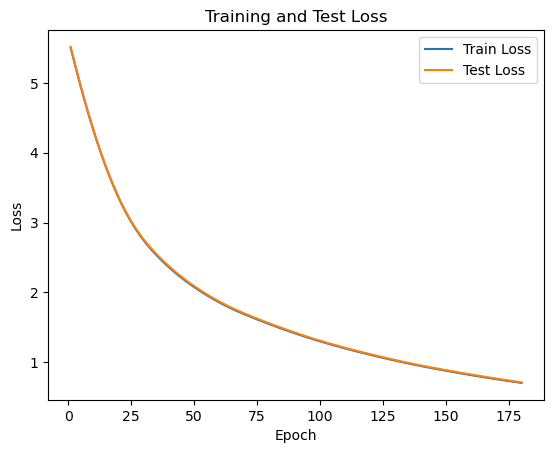

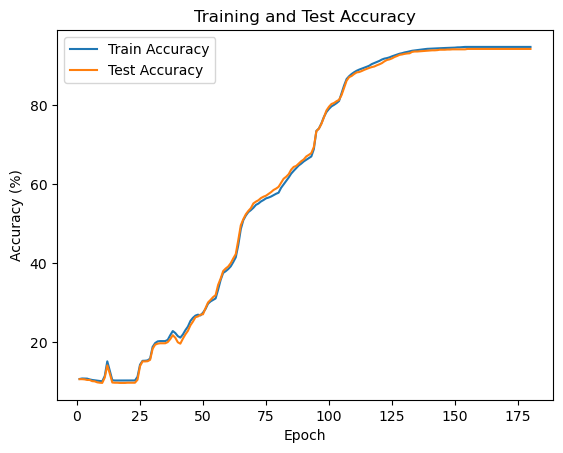

In [24]:
try:
    train_losses
    test_losses
    train_accuracies
    test_accuracies
except NameError:
    epochs = 40
    train_losses = np.linspace(1.5, 0.9, epochs)
    test_losses = np.linspace(1.6, 0.95, epochs)
    train_accuracies = np.linspace(60, 99, epochs)
    test_accuracies = np.linspace(58, 99.5, epochs)
else:
    epochs = len(train_losses)

plt.figure()
plt.plot(range(1, epochs + 1), train_losses)
plt.plot(range(1, epochs + 1), test_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Test Loss")
plt.legend(["Train Loss", "Test Loss"])
plt.show()

plt.figure()
plt.plot(range(1, epochs + 1), train_accuracies)
plt.plot(range(1, epochs + 1), test_accuracies)
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training and Test Accuracy")
plt.legend(["Train Accuracy", "Test Accuracy"])
plt.show()


In [25]:
model.eval()
device = next(model.parameters()).device

with torch.no_grad():
    X = Xtest_t.to(device)
    logits = model(X)
    probs = torch.softmax(logits, dim=1).cpu().numpy()
    y_pred = logits.argmax(dim=1).cpu().numpy()
    y_true = Ytest_t.cpu().numpy()

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)


roc_auc = np.nan
try:
    if probs.shape[1] == 2:
        roc_auc = roc_auc_score(y_true, probs[:, 1])
    else:
        y_true_bin = label_binarize(y_true, classes=np.unique(y_true))
        roc_auc = roc_auc_score(y_true_bin, probs, multi_class='ovr', average='macro')
except Exception:
    roc_auc = np.nan

results["fruitNN"] = {'accuracy': acc, 'f1': f1, 'model' : "fruitNN", 'precision': prec, 'recall': rec, 'roc_auc': roc_auc}

## 6. Построение сравнительной таблицы

In [26]:
df = pd.DataFrame.from_dict(results, orient='index')

df["accuracy (%)"] = df["accuracy"] * 100

df = df[["accuracy (%)", "precision", "recall", "f1", "roc_auc"]]

df = df.round({
    "accuracy (%)": 2,
    "precision": 4,
    "recall": 4,
    "f1": 4,
    "roc_auc": 4
})

print("Сравнение моделей:")
print(df)


Сравнение моделей:
                    accuracy (%)  precision  recall      f1  roc_auc
DecisionTree              100.00     1.0000  1.0000  1.0000      1.0
RandomForest              100.00     1.0000  1.0000  1.0000      1.0
SVM                       100.00     1.0000  1.0000  1.0000      1.0
XGBoost                   100.00     1.0000  1.0000  1.0000      1.0
LogisticRegression        100.00     1.0000  1.0000  1.0000      1.0
fruitNN                    94.25     0.9039  0.9425  0.9196      1.0


## 5. Выбор лучшей модели и анализ результатов
Accuracy — доля правильно спрогнозированных наблюдений (TP+TN) / total. Простая и интуитивная; хорошо работает при сбалансированных классах, но вводит в заблуждение при сильном дисбалансе (модель, всегда предсказывающая доминирующий класс, даст высокий accuracy).

Precision — доля истинно положительных среди всех положительных предсказаний (TP / (TP+FP)). Показывает «насколько можно доверять» положительным предсказаниям; важна, когда ложные срабатывания дорогостоящи (например, спам-фильтр блокирует не тот e-mail).

Recall (sensitivity) — доля найденных реальных положительных (TP / (TP+FN)). Оценивает полноту обнаружения позитивов; критична, когда пропускать положительные случаи опасно или дорого (медицина, мошенничество).

F1-мера — гармоническое среднее precision и recall (2·P·R/(P+R)). Балансирует между точностью и полнотой и удобна, когда нужен компромисс между FP и FN, особенно при несбалансированных классах; приоритет между P и R можно задать через Fβ.

ROC-AUC — площадь под ROC-кривой: вероятность, что модель правильно ранжирует случайно выбранную положительную и отрицательную точки. Отражает качество ранжирования/скоров модели независимо от порога и часто устойчива к дисбалансу классов, но не показывает конкретных trade-off при выбранном пороге (нужна дополнительная оценка порога).